In [1]:
class DoubleVoigtFit:
    def __init__(self, mass, fit_values, ax=None, color=None, masse =[25, 50, 75, 100, 125, 150, 175, 200]):
        self.mass=mass
        self.fit_values = fit_values
        self.ax = ax
        self.color = color
        self.masse = masse

    def get_fit_parameters(self):
        # Interpoliamo i parametri per la massa specificata
        norm_interp = interp1d(self.masse, [fit["norm"] for fit in self.fit_values.values()], kind='linear', fill_value='extrapolate')
        norm2_interp = interp1d(self.masse, [fit["norm2"] for fit in self.fit_values.values()], kind='linear', fill_value='extrapolate')
        mu_interp = interp1d(self.masse, [fit["mu"] for fit in self.fit_values.values()], kind='linear', fill_value='extrapolate')
        mu2_interp = interp1d(self.masse, [fit["mu2"] for fit in self.fit_values.values()], kind='linear', fill_value='extrapolate')
        sigma_interp = interp1d(self.masse, [fit["sigma"] for fit in self.fit_values.values()], kind='linear', fill_value='extrapolate')
        sigma2_interp = interp1d(self.masse, [fit["sigma2"] for fit in self.fit_values.values()], kind='linear', fill_value='extrapolate')
        gamma_interp = interp1d(self.masse, [fit["gamma"] for fit in self.fit_values.values()], kind='linear', fill_value='extrapolate')
        gamma2_interp = interp1d(self.masse, [fit["gamma2"] for fit in self.fit_values.values()], kind='linear', fill_value='extrapolate')

        return {
            "norm": norm_interp(self.mass),
            "norm2": norm2_interp(self.mass),
            "mu": mu_interp(self.mass),
            "mu2": mu2_interp(self.mass),
            "sigma": sigma_interp(self.mass),
            "sigma2": sigma2_interp(self.mass),
            "gamma": gamma_interp(self.mass),
            "gamma2": gamma2_interp(self.mass)
        }
    
    def grafico(self, ax=None, color=None):
        fit_parameters = self.get_fit_parameters()
        x = np.linspace(0, 250, 300)
        y = voigt2(x, fit_parameters["norm"], fit_parameters["mu"], fit_parameters["sigma"], fit_parameters["gamma"], fit_parameters["norm2"], 
                   fit_parameters["mu2"], fit_parameters["sigma2"], fit_parameters["gamma2"])
        
        
        if ax is None:
            plt.figure(figsize=(10, 6))
        else:
            plt.sca(ax)
        plt.plot(x, y, label=f'Interpolatepolazione per le Masse {self.mass}', color=self.color)
        plt.title(f'Interpolazione per la Massa {self.mass}')
        plt.xlabel('Massa')
        plt.ylabel('Densità')
        plt.legend()
        plt.grid()
        
        return

In [2]:
import json

with open("fit_values.json", "r") as f:
    values = json.load(f)

masse=[25, 50, 75, 100, 125, 150, 175, 200]
fit_MH_values=values

from Utilities_copy import voigt2
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

class DoubleVoigtFit:
    def __init__(self, mass, fit_values, ax=None, color=None):
        self.mass = mass
        self.ax = ax
        self.color = color
        
        self.fit_values = {}
        
        
        for key, params in fit_values.items():
            if key == "MH50":
                continue  
                
            
            if str(key).startswith("MH"):
                numeric_mass = float(key.replace("MH", ""))
                self.fit_values[numeric_mass] = params

        self.masse = sorted(self.fit_values.keys())

    def get_fit_parameters(self):
    
        def get_param_list(param_name):
            return [self.fit_values[m][param_name] for m in self.masse]

        norm_interp = interp1d(self.masse, get_param_list("norm"), kind='linear', fill_value='extrapolate')
        norm2_interp = interp1d(self.masse, get_param_list("norm2"), kind='linear', fill_value='extrapolate')
        mu_interp = interp1d(self.masse, get_param_list("mu"), kind='linear', fill_value='extrapolate')
        mu2_interp = interp1d(self.masse, get_param_list("mu2"), kind='linear', fill_value='extrapolate')
        sigma_interp = interp1d(self.masse, get_param_list("sigma"), kind='linear', fill_value='extrapolate')
        sigma2_interp = interp1d(self.masse, get_param_list("sigma2"), kind='linear', fill_value='extrapolate')
        gamma_interp = interp1d(self.masse, get_param_list("gamma"), kind='linear', fill_value='extrapolate')
        gamma2_interp = interp1d(self.masse, get_param_list("gamma2"), kind='linear', fill_value='extrapolate')

        return {
            "norm": norm_interp(self.mass),
            "norm2": norm2_interp(self.mass),
            "mu": mu_interp(self.mass),
            "mu2": mu2_interp(self.mass),
            "sigma": sigma_interp(self.mass),
            "sigma2": sigma2_interp(self.mass),
            "gamma": gamma_interp(self.mass),
            "gamma2": gamma2_interp(self.mass)
        }
    
    def grafico(self):
        fit_parameters = self.get_fit_parameters()
        x = np.linspace(0, 250, 300)
        
        y = voigt2(x, 
                   fit_parameters["norm"], fit_parameters["mu"], fit_parameters["sigma"], fit_parameters["gamma"], 
                   fit_parameters["norm2"], fit_parameters["mu2"], fit_parameters["sigma2"], fit_parameters["gamma2"])
        
        if self.ax is None:
            plt.figure(figsize=(10, 6))
            ax = plt.gca()
        else:
            ax = self.ax
            plt.sca(ax)
            
        ax.plot(x, y, label=f'Curva Interpolata (Massa {self.mass})', color=self.color)
        ax.set_title(f'Interpolazione per la Massa {self.mass}')
        ax.set_xlabel('Massa')
        ax.set_ylabel('Densità')
        ax.legend()
        ax.grid(True)
        
        return

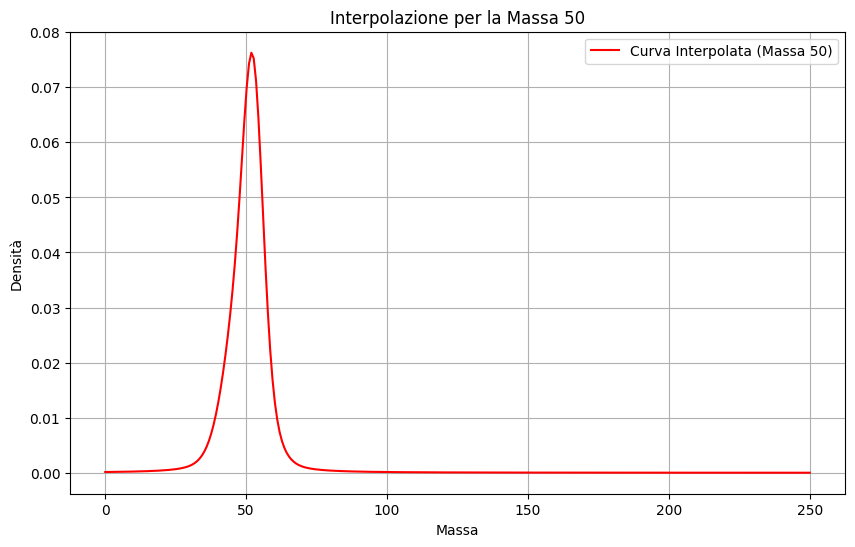

In [3]:
fit_massa_50 = DoubleVoigtFit(mass=50, fit_values=fit_MH_values, color='red')
fit_massa_50.grafico()
plt.show()

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

class DoubleVoigtFit2:
    def __init__(self, mass, fit_values, exclude_mass=50, ax=None, color=None):
        self.mass = mass
        self.ax = ax
        self.color = color
        
        self.param_names = ["norm", "mu", "sigma", "gamma", "norm2", "mu2", "sigma2", "gamma2"]
        
        exclude_key = f"MH{exclude_mass}"
        cleaned_data = {float(k.replace("MH", "")): params for k, params in fit_values.items() if str(k).startswith("MH") and k != exclude_key}

        self.masse = sorted(cleaned_data.keys())

        self.y_params = np.array([[cleaned_data[m][p] for m in self.masse] for p in self.param_names])

    def get_fit_parameters(self):
        interpolator = interp1d(self.masse, self.y_params, kind='linear', fill_value='extrapolate')
        
        interpolated_values = interpolator(self.mass)
        
        return dict(zip(self.param_names, interpolated_values))
    
    def grafico(self):
        fit_params = self.get_fit_parameters()
        x = np.linspace(0, 250, 300)
        
       
        args_for_voigt = [fit_params[p] for p in self.param_names]
        y = voigt2(x, *args_for_voigt)
        
        ax = self.ax if self.ax is not None else plt.subplots(figsize=(10, 6))[1]
            
        ax.plot(x, y, label=f'Curva Interpolata (Massa {self.mass})', color=self.color)
        ax.set_title(f'Interpolazione per la Massa {self.mass}')
        ax.set_xlabel('Massa')
        ax.set_ylabel('Densità')
        ax.legend()
        ax.grid(True)

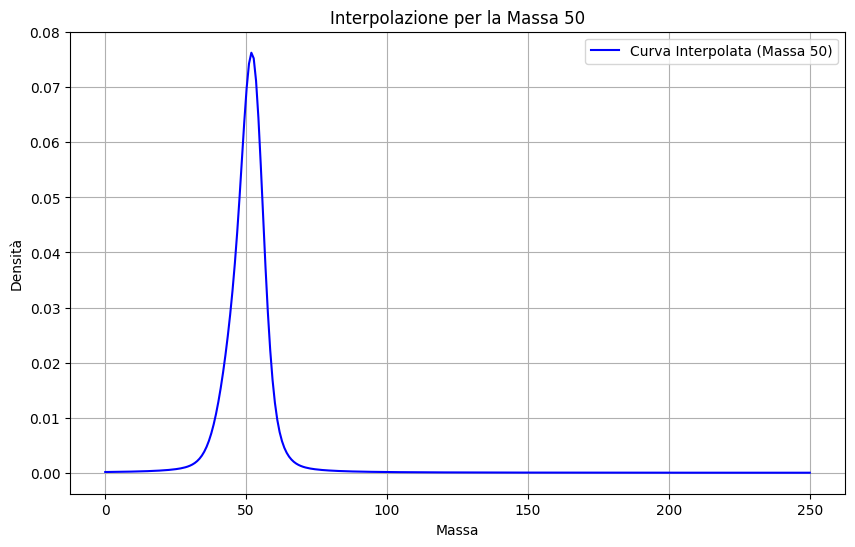

In [5]:
fit_massa_50_v2 = DoubleVoigtFit2(mass=50, fit_values=fit_MH_values, color='blue')
fit_massa_50_v2.grafico()
plt.show()